In [1]:
import pandas as pd

In [2]:
data = pd.read_csv("../../../data/raw/kathmandu_full_raw_2023_2024.csv")

In [3]:
data['time'] = pd.to_datetime(data['time'])

### 13. Analyze monthly and seasonal variations

month
1     46.166734
2     38.645687
3     31.718683
4     27.412292
5     30.987298
6     29.503264
7     14.953024
8     17.642540
9     17.667778
10    24.506384
11    40.846181
12    48.336828
Name: pm2_5, dtype: float64


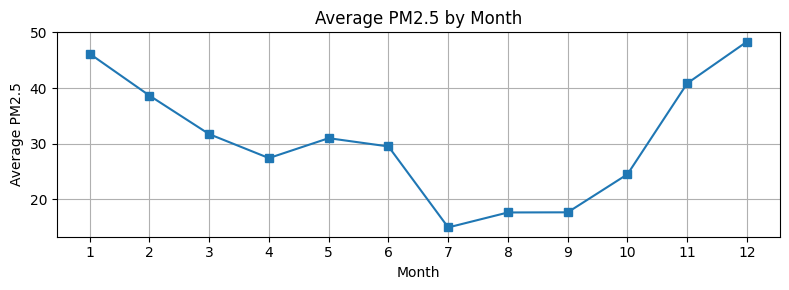

In [4]:
import matplotlib.pyplot as plt

data['month'] = data['time'].dt.month
monthly_avg = data.groupby('month')['pm2_5'].mean()

print(monthly_avg)

plt.figure(figsize=(8, 3))
plt.plot(monthly_avg.index, monthly_avg.values, marker='s')
plt.title('Average PM2.5 by Month')
plt.xlabel('Month')
plt.ylabel('Average PM2.5')
plt.xticks(range(1, 13))
plt.grid(True)
plt.tight_layout()
plt.show()

#### 13.1 Sample months hourly analysis

2024 7
hour
0     16.577419
1     15.480645
2     14.493548
3     13.509677
4     12.780645
5     13.022581
6     14.367742
7     13.658065
8     12.606452
9     12.129032
10    11.941935
11    11.345161
12    10.912903
13    11.006452
14    11.522581
15    11.541935
16    11.229032
17    15.229032
18    16.658065
19    19.303226
20    20.454839
21    20.377419
22    19.629032
23    18.051613
Name: pm2_5, dtype: float64
2023 3
hour
0     40.929032
1     39.500000
2     38.080645
3     36.948387
4     36.319355
5     36.293548
6     37.651613
7     39.064516
8     31.667742
9     29.429032
10    28.270968
11    27.545161
12    27.119355
13    27.116129
14    27.238710
15    27.567742
16    28.196774
17    33.212903
18    35.548387
19    37.445161
20    39.080645
21    40.745161
22    42.151613
23    42.235484
Name: pm2_5, dtype: float64
2023 12
hour
0     39.045161
1     35.712903
2     33.067742
3     31.203226
4     30.012903
5     29.474194
6     34.377419
7     41.358065
8     41.73

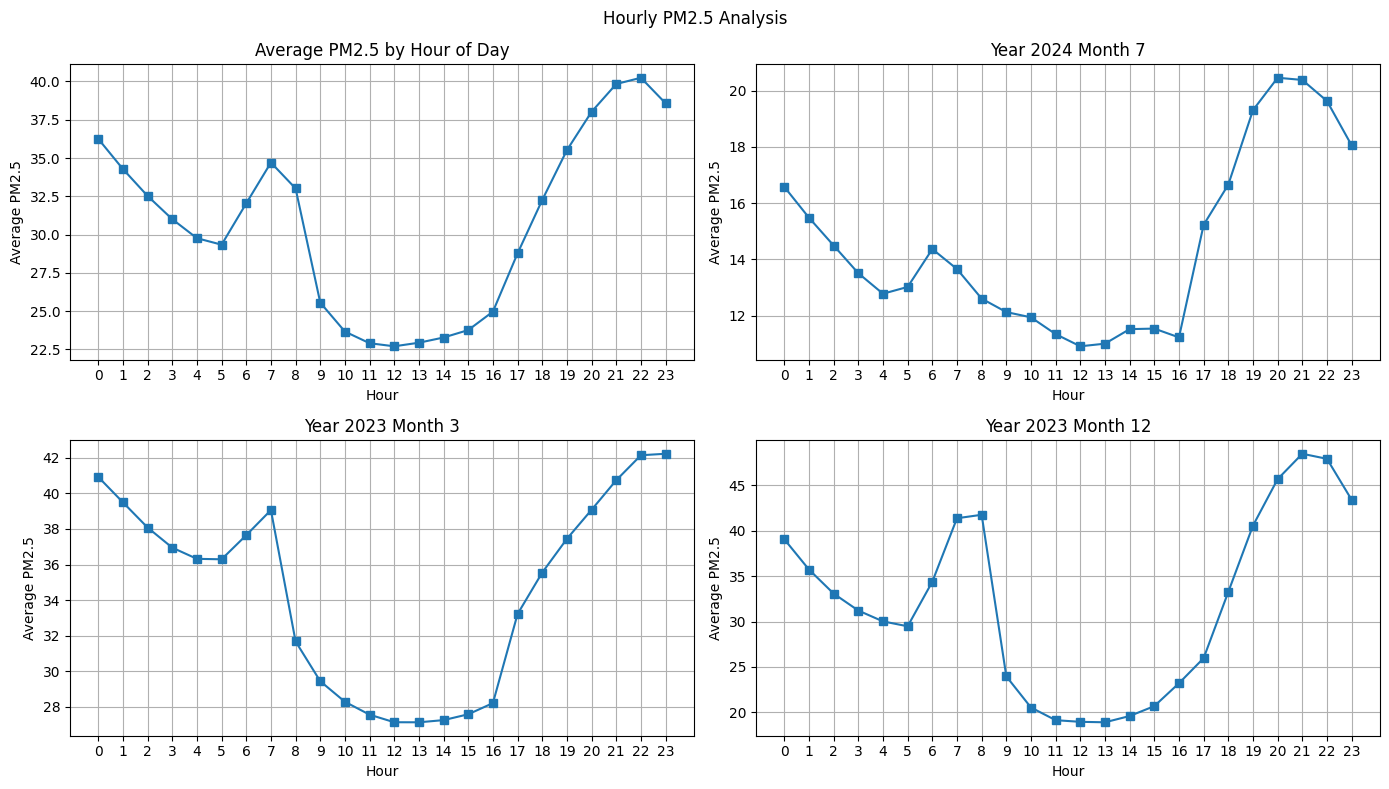

In [5]:
data['hour'] = data['time'].dt.hour
data['month'] = data['time'].dt.month
data['year'] = data['time'].dt.year

hourly_avg = data.groupby('hour')['pm2_5'].mean()
months = data[['year', 'month']].drop_duplicates().sample(3, random_state=44).values

for i, (year, month) in enumerate(months):
    mask = (data['year'] == year) & (data['month'] == month)
    month_data = data[mask].groupby('hour')['pm2_5'].mean()
    print(year, month)
    print(month_data)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

axes[0].plot(hourly_avg.index, hourly_avg.values, marker='s')
axes[0].set_title('Average PM2.5 by Hour of Day')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Average PM2.5')
axes[0].set_xticks(range(0, 24))
axes[0].grid(True)

for i, (year, month) in enumerate(months):
    mask = (data['year'] == year) & (data['month'] == month)
    month_data = data[mask].groupby('hour')['pm2_5'].mean()
    axes[i + 1].plot(month_data.index, month_data.values, marker='s')
    axes[i + 1].set_title(f'Year {year} Month {month}')
    axes[i + 1].set_xlabel('Hour')
    axes[i + 1].set_ylabel('Average PM2.5')
    axes[i + 1].set_xticks(range(0, 24))
    axes[i + 1].grid(True)

plt.suptitle('Hourly PM2.5 Analysis')
plt.tight_layout()
plt.show()

### 14. Compute moving averages and moving volatility

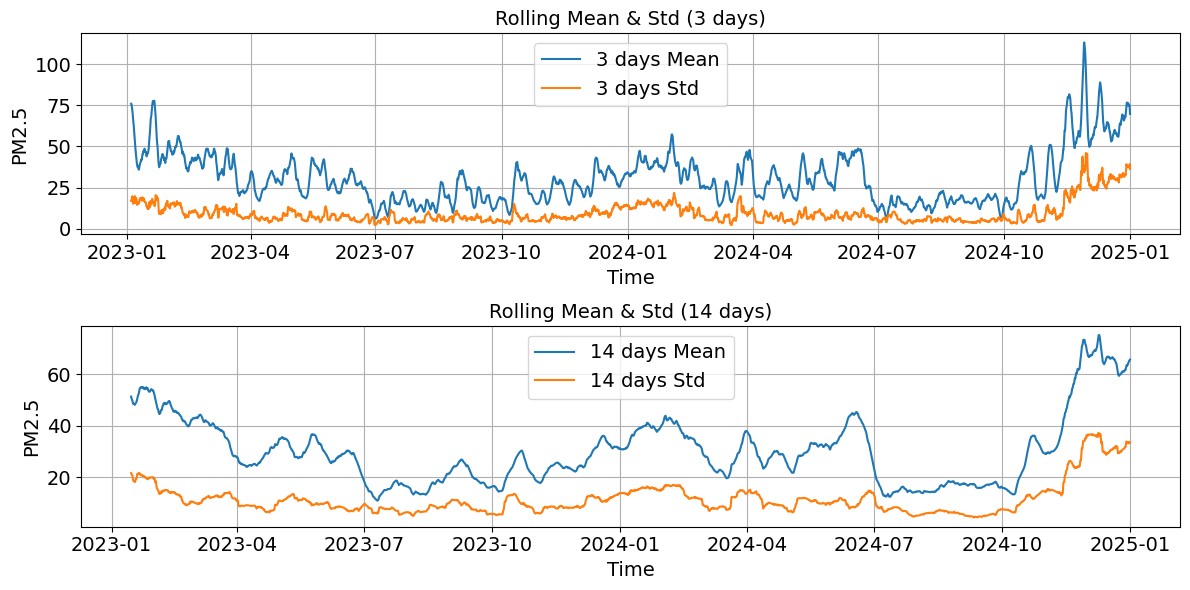

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes = axes.flatten()

windows = [72, 336]

for i, w in enumerate(windows):
    axes[i].plot(data['time'], data['pm2_5'].rolling(window=w).mean(), label=f'{int(w/24)} days Mean')
    axes[i].plot(data['time'], data['pm2_5'].rolling(window=w).std(), label=f'{int(w/24)} days Std')

    axes[i].set_title(f'Rolling Mean & Std ({int(w/24)} days)', fontsize=14)
    axes[i].set_xlabel('Time', fontsize=14)
    axes[i].set_ylabel('PM2.5', fontsize=14)

    axes[i].tick_params(axis='both', labelsize=14)
    axes[i].legend(fontsize=14)
    axes[i].grid(True)

plt.tight_layout()
plt.show()